# Preprocesamiento y Modelado con scikit-learn


##  Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.ensemble       import RandomForestClassifier
from sklearn.metrics        import (accuracy_score, precision_score, recall_score,
                                    f1_score, roc_auc_score, confusion_matrix,
                                    ConfusionMatrixDisplay, roc_curve)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

##  Carga del Dataset

In [2]:
df = pd.read_csv('df_clean.csv', low_memory=False)
print(f'Shape : {df.shape}')
df.head(3)

Shape : (1345310, 93)


,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,default
0,68407277,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,...,0.0,0.0,178050.0,7746.0,2400.0,13734.0,N,Cash,N,0.0
1,68355089,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,...,0.0,0.0,314017.0,39475.0,79300.0,24667.0,N,Cash,N,0.0
2,68341763,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,...,0.0,0.0,218418.0,18696.0,6200.0,14877.0,N,Cash,N,0.0


---
# Parte 1: Preprocesamiento

##  Selección de Variables

In [3]:
FEATURES = [c for c in [
    'loan_amnt', 'int_rate', 'fico_range_high', 'emp_length',
    'annual_inc', 'purpose', 'home_ownership', 'dti',
    'term', 'sub_grade', 'verification_status',
    'open_acc', 'pub_rec', 'revol_util', 'mort_acc'
] if c in df.columns]

TARGET = 'default'

X = df[FEATURES].copy()
y = df[TARGET].copy()

NUM_COLS = X.select_dtypes(include='number').columns.tolist()
CAT_COLS = X.select_dtypes(include='object').columns.tolist()

print(f'Features   : {len(FEATURES)}')
print(f'Numéricas  : {NUM_COLS}')
print(f'Categóricas: {CAT_COLS}')

Features   : 15
Numéricas  : ['loan_amnt', 'int_rate', 'fico_range_high', 'emp_length', 'annual_inc', 'dti', 'open_acc', 'pub_rec', 'revol_util', 'mort_acc']
Categóricas: ['purpose', 'home_ownership', 'term', 'sub_grade', 'verification_status']


##  Submuestreo para entrenamiento



In [4]:
SAMPLE_SIZE = 500_000   

X_sample, _, y_sample, _ = train_test_split(
    X, y, train_size=SAMPLE_SIZE, stratify=y, random_state=42
)

print(f'Muestra: {len(X_sample):,} filas')
print(f'  Fully Paid  (0): {(y_sample==0).sum():,}  ({(y_sample==0).mean()*100:.1f}%)')
print(f'  Charged Off (1): {(y_sample==1).sum():,}  ({(y_sample==1).mean()*100:.1f}%)')

Muestra: 500,000 filas
  Fully Paid  (0): 400,187  (80.0%)
  Charged Off (1): 99,813  (20.0%)


##  División Train/Test 

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.20, random_state=42, stratify=y_sample
)

print(f'Train: {X_train.shape[0]:,} filas')
print(f'Test : {X_test.shape[0]:,} filas')

Train: 400,000 filas
Test : 100,000 filas


##  Codificación de Variables Categóricas

In [6]:
label_cols = [c for c in ['sub_grade', 'term'] if c in CAT_COLS]
ohe_cols   = [c for c in CAT_COLS if c not in label_cols]

le_encoders = {}
for col in label_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col]  = le.transform(X_test[col].astype(str))
    le_encoders[col] = le

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
X_train_ohe = ohe.fit_transform(X_train[ohe_cols])
X_test_ohe  = ohe.transform(X_test[ohe_cols])
ohe_names   = ohe.get_feature_names_out(ohe_cols)

num_label = NUM_COLS + label_cols

X_train_enc = pd.concat([X_train[num_label].reset_index(drop=True),
                          pd.DataFrame(X_train_ohe, columns=ohe_names)], axis=1)
X_test_enc  = pd.concat([X_test[num_label].reset_index(drop=True),
                          pd.DataFrame(X_test_ohe,  columns=ohe_names)], axis=1)

print(f' Codificación completa — Shape: {X_train_enc.shape}')

 Codificación completa — Shape: (400000, 32)


##  Escalado con StandardScaler

In [7]:
scaler = StandardScaler()
X_train_enc[NUM_COLS] = scaler.fit_transform(X_train_enc[NUM_COLS])
X_test_enc[NUM_COLS]  = scaler.transform(X_test_enc[NUM_COLS])


---
# Parte 2: Modelado

##  Búsqueda Manual de Hiperparámetros



In [8]:
n_estimators_list = [10, 50, 100]
max_depth_list     = [5, 10, 15]

results = []

print(f'{"n_est":>6} {"max_d":>6} {"ROC_AUC":>10} {"Tiempo(s)":>10}')
print('-' * 38)

for n_est in n_estimators_list:
    for max_d in max_depth_list:
        rf = RandomForestClassifier(
            n_estimators = n_est,
            max_depth    = max_d,
            class_weight = 'balanced',
            random_state = 42,
            n_jobs       = -1
        )
        t0    = time.time()
        rf.fit(X_train_enc, y_train)
        t_fit = time.time() - t0

        proba = rf.predict_proba(X_test_enc)[:, 1]
        auc   = roc_auc_score(y_test, proba)

        results.append({'n_estimators': n_est, 'max_depth': max_d,
                        'roc_auc': auc, 'train_time': t_fit, 'model': rf, 'proba': proba})

        print(f'{n_est:>6} {max_d:>6} {auc:>10.4f} {t_fit:>10.2f}')

 n_est  max_d    ROC_AUC  Tiempo(s)
--------------------------------------
    10      5     0.7055       0.31
    10     10     0.7111       0.44
    10     15     0.7034       0.60
    50      5     0.7082       1.20
    50     10     0.7145       1.93
    50     15     0.7123       2.22
   100      5     0.7087       2.29
   100     10     0.7149       3.18
   100     15     0.7138       4.39


###  Heatmap de resultados

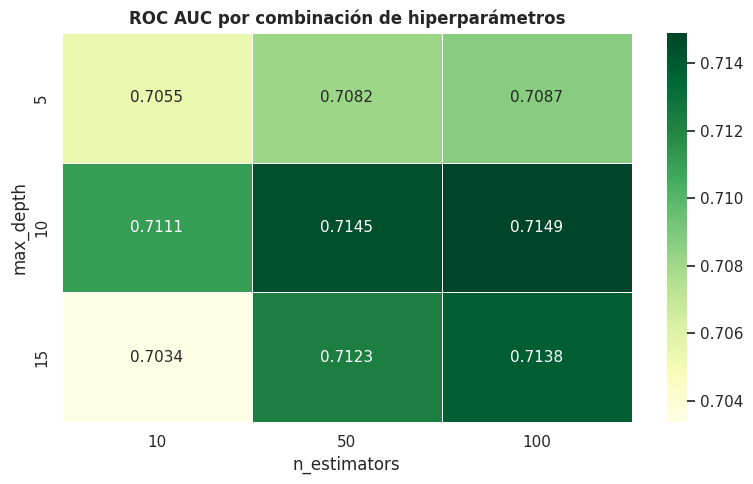

In [9]:
df_res = pd.DataFrame([{k: v for k, v in r.items() if k not in ('model', 'proba')}
                        for r in results])

pivot = df_res.pivot(index='max_depth', columns='n_estimators', values='roc_auc')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGn',
            linewidths=0.5, ax=ax, annot_kws={'size': 11})
ax.set_title('ROC AUC por combinación de hiperparámetros', fontweight='bold')
ax.set_xlabel('n_estimators')
ax.set_ylabel('max_depth')
plt.tight_layout()
plt.savefig('sklearn_01_heatmap.png', bbox_inches='tight')
plt.show()

##  Mejor Modelo 

In [10]:
best = max(results, key=lambda r: r['roc_auc'])
best_model = best['model']

print(f'Mejor configuración:')
print(f'  n_estimators: {best["n_estimators"]}')
print(f'  max_depth   : {best["max_depth"]}')
print(f'  ROC AUC     : {best["roc_auc"]:.4f}')

t_pred_start = time.time()
y_pred       = best_model.predict(X_test_enc)
y_pred_proba = best_model.predict_proba(X_test_enc)[:, 1]
t_pred       = time.time() - t_pred_start

Mejor configuración:
  n_estimators: 100
  max_depth   : 10
  ROC AUC     : 0.7149


##  Métricas

In [11]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_pred_proba)

print('=' * 42)
print('   MÉTRICAS — RandomForest (sklearn)')
print('=' * 42)
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-score  : {f1:.4f}')
print(f'  ROC AUC   : {auc:.4f}')
print('-' * 42)
print(f'  Tiempo entrenamiento: {best["train_time"]:.2f} s')
print(f'  Tiempo predicción   : {t_pred:.4f} s')
print('=' * 42)

   MÉTRICAS — RandomForest (sklearn)
  Accuracy  : 0.6427
  Precision : 0.3160
  Recall    : 0.6779
  F1-score  : 0.4310
  ROC AUC   : 0.7149
------------------------------------------
  Tiempo entrenamiento: 3.18 s
  Tiempo predicción   : 0.1473 s


##  Matriz de Confusión y Curva ROC

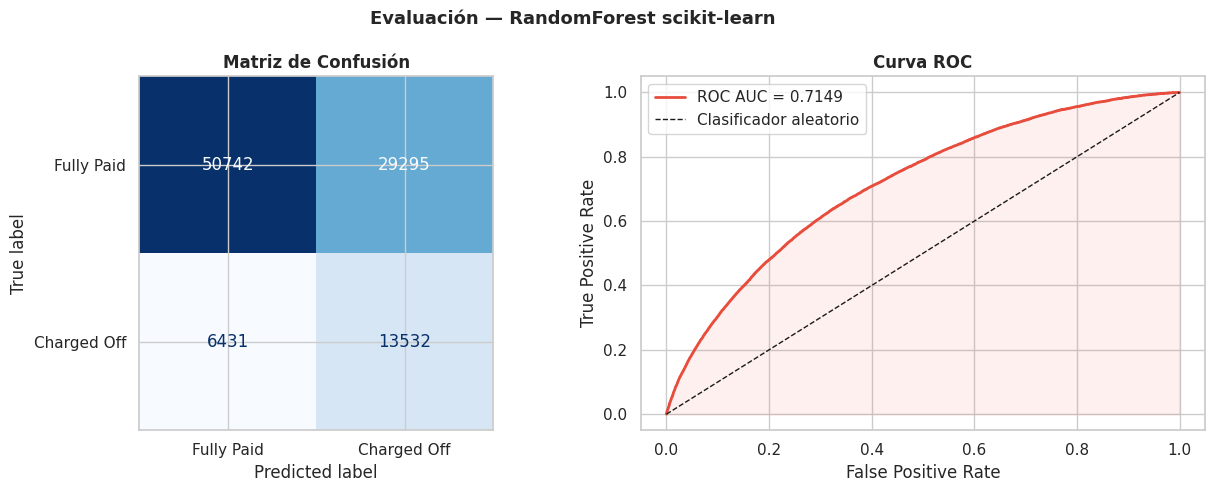

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Fully Paid', 'Charged Off']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión', fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1],'k--', lw=1, label='Clasificador aleatorio')
axes[1].fill_between(fpr, tpr, alpha=0.08, color='#e74c3c')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC', fontweight='bold')
axes[1].legend()

plt.suptitle('Evaluación — RandomForest scikit-learn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sklearn_02_evaluation.png', bbox_inches='tight')
plt.show()

##  Importancia de Variables

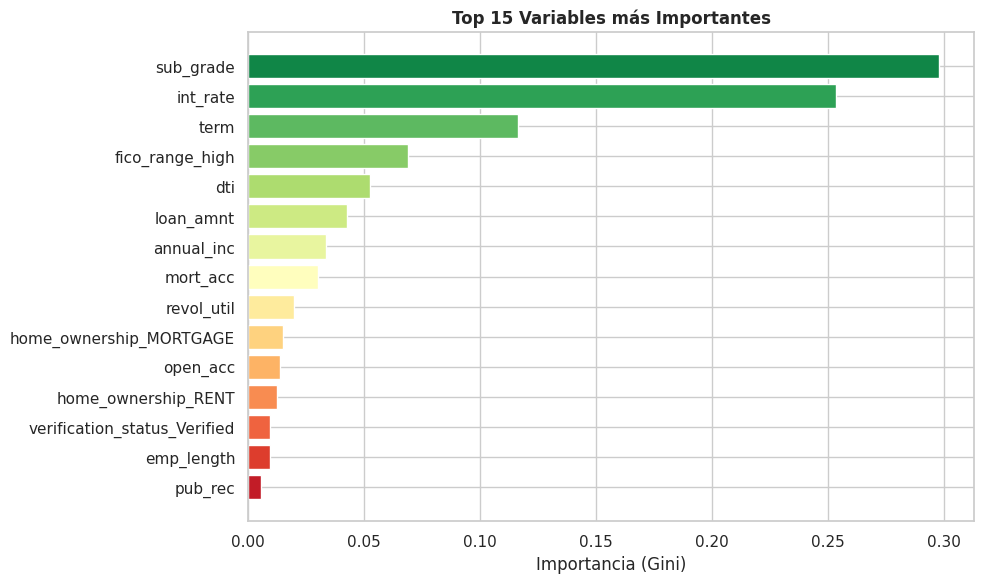

In [13]:
importances = pd.Series(best_model.feature_importances_,
                         index=X_train_enc.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importances.index[::-1], importances.values[::-1],
        color=sns.color_palette('RdYlGn_r', 15)[::-1], edgecolor='white')
ax.set_xlabel('Importancia (Gini)')
ax.set_title('Top 15 Variables más Importantes', fontweight='bold')
plt.tight_layout()
plt.savefig('sklearn_03_importance.png', bbox_inches='tight')
plt.show()

##  Guardar Métricas

In [14]:
import json

metrics_sklearn = {
    'Modelo'        : 'RandomForest (sklearn)',
    'n_estimators'  : best['n_estimators'],
    'max_depth'     : best['max_depth'],
    'Accuracy'      : round(acc,  4),
    'Precision'     : round(prec, 4),
    'Recall'        : round(rec,  4),
    'F1-score'      : round(f1,   4),
    'ROC_AUC'       : round(auc,  4),
    'Tiempo_train_s': round(best['train_time'], 2),
    'Tiempo_pred_s' : round(t_pred, 4)
}

with open('metrics_sklearn.json', 'w') as f:
    json.dump(metrics_sklearn, f, indent=2)

pd.DataFrame([metrics_sklearn])

,Modelo,n_estimators,max_depth,Accuracy,Precision,Recall,F1-score,ROC_AUC,Tiempo_train_s,Tiempo_pred_s
0,RandomForest (sklearn),100,10,0.6427,0.316,0.6779,0.431,0.7149,3.18,0.1473
